# CNN

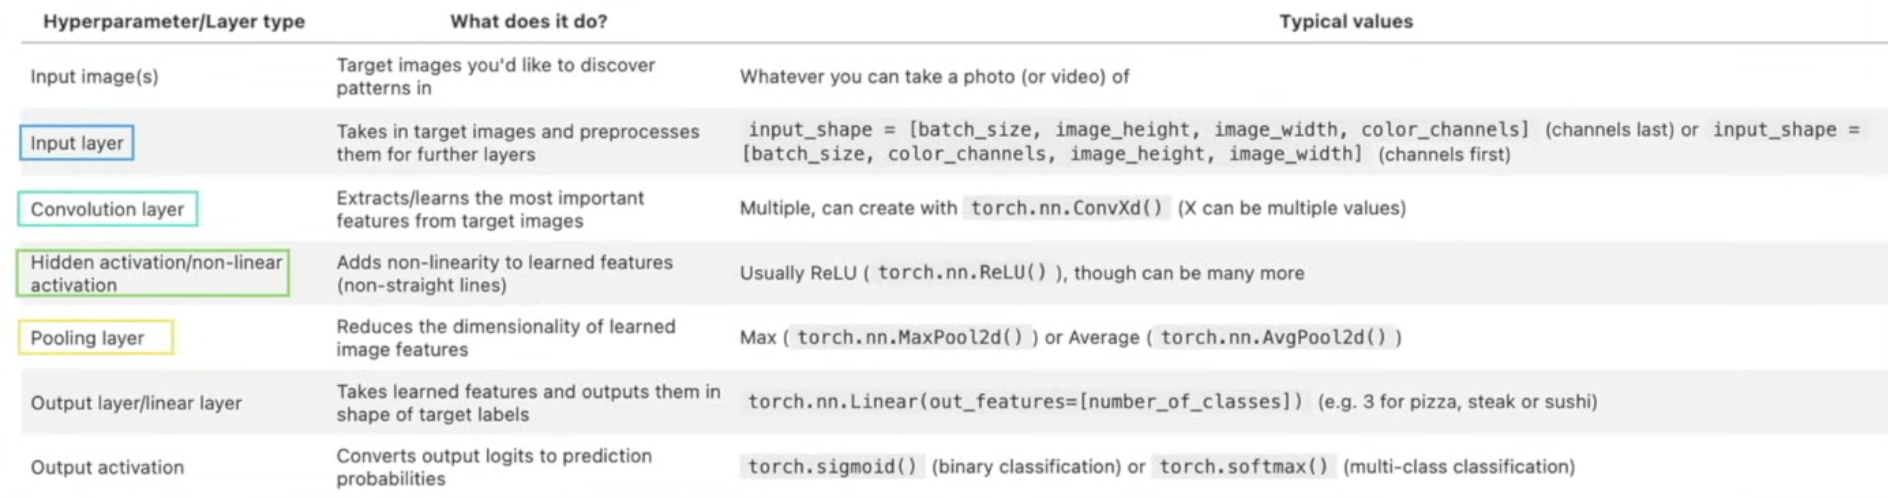

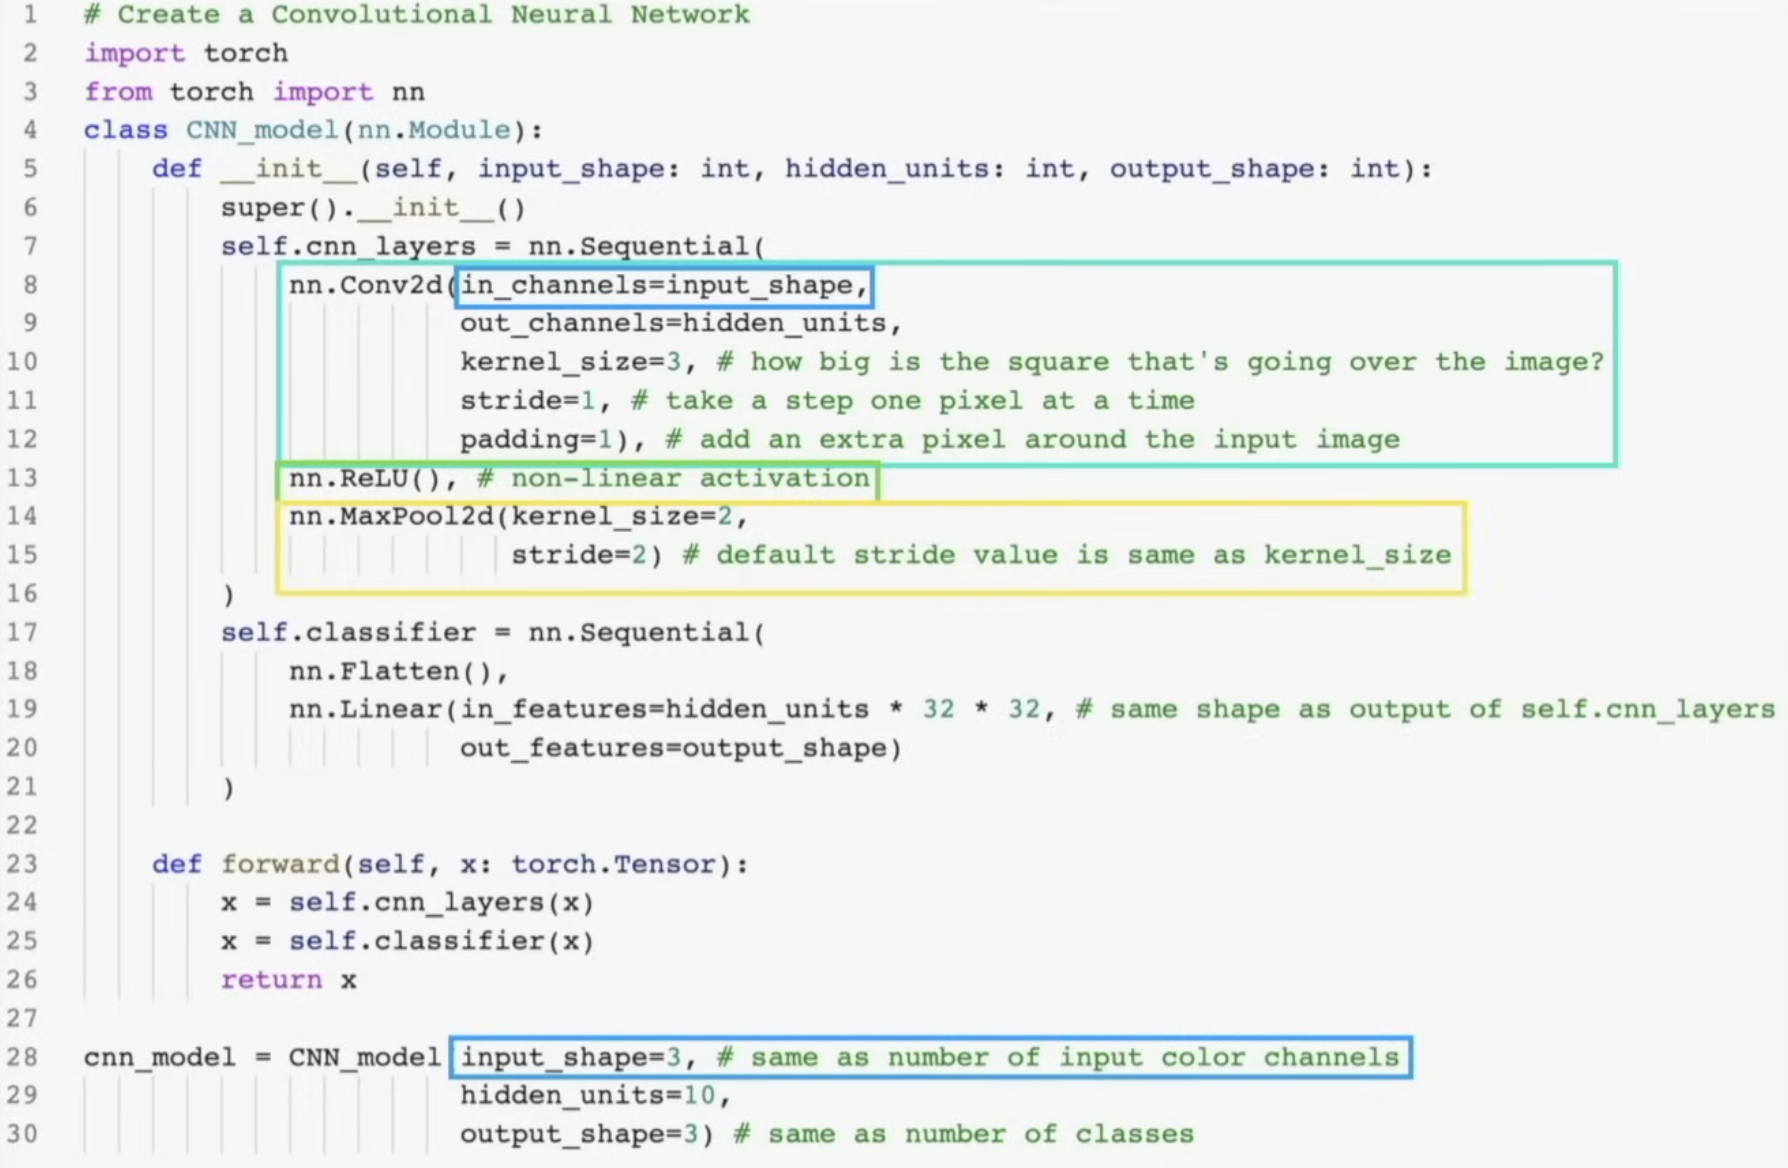

In [2]:
import torch 
from torch import nn
import torchvision
from torchvision import transforms
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

torchvision.__version__



'0.25.0'

In [3]:
train_dataset = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)
test_dataset = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

In [4]:
len(train_dataset), len(test_dataset)

(60000, 10000)

In [5]:

image, label = train_dataset[0]
image

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
          0.2863, 0.0000, 0.0000, 0.0039, 0.0157, 0.0000,

In [6]:
class_names = train_dataset.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [7]:
image.shape, label, class_names[label]

(torch.Size([1, 28, 28]), 9, 'Ankle boot')

In [8]:
train_dataset

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

Image shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, 'Ankle boot')

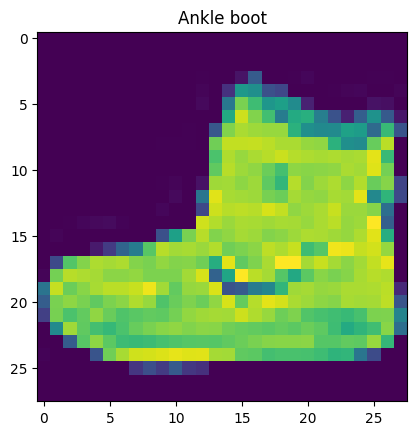

In [9]:
image, label = train_dataset[0]
print(f"Image shape: {image.shape}")
plt.imshow(image.squeeze())
plt.title(class_names[label])

In [10]:
import numpy as np
from collections import Counter

# Count labels in train dataset
train_labels = train_dataset.targets.numpy()
label_counts = Counter(train_labels)

print("Label Value Counts (Train Dataset):\n")
for idx in sorted(label_counts):
    print(f"  {idx} ({class_names[idx]}): {label_counts[idx]}")

Label Value Counts (Train Dataset):

  0 (T-shirt/top): 6000
  1 (Trouser): 6000
  2 (Pullover): 6000
  3 (Dress): 6000
  4 (Coat): 6000
  5 (Sandal): 6000
  6 (Shirt): 6000
  7 (Sneaker): 6000
  8 (Bag): 6000
  9 (Ankle boot): 6000


## preparing our dataset
dividing our dataset in mini batches to :
* it is more efficient way to make our model look at all the images commonly 32 batch size 
* it gives our model more chance  to update it's gradient per epoch 

In [11]:
from torch.utils.data import DataLoader
from torch.utils.data._utils.collate import default_collate
BATCH_SIZE = 32
device = 'cpu'

def collate_to_device(batch):
    X, y = default_collate(batch)
    return X.to(device), y.to(device)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_to_device
)
test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_to_device
)
len(train_dataloader), len(test_dataloader)

(1875, 313)

### checking inside the dataloader 

In [12]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Randomly selected image index: 7542
Image shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, 'Ankle boot')

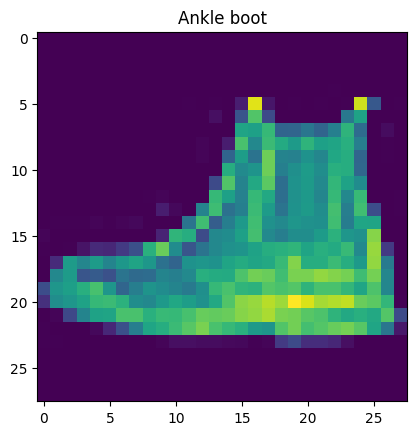

In [13]:
torch.manual_seed(42)
random_idx = torch.randint(0, len(test_dataset), size=[1]).item()
random_image, random_label = test_dataset[random_idx]
print(f"Randomly selected image index: {random_idx}")
print(f"Image shape: {random_image.shape}")
plt.imshow(random_image.squeeze())
plt.title(class_names[random_label])

## building the model 
smart simpler and add complexity 

In [14]:
flatten_image = nn.Flatten()
x = train_features_batch[4]
output = flatten_image(x)
output.squeeze(),output.shape

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.1804, 0.6745, 0.8000, 0.7059, 0.4392, 0.4784, 0.7765, 0.7882,
         0.2902, 0.0314, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000,
         0.5294, 0.7765, 0.8118, 0.7490, 0.8549, 1.0000, 0.2471, 0.4902, 1.0000,
         0.7294, 0.6863, 0.7294, 0.5765, 0.0510, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.5725, 0.7725, 0.6863, 0.6784, 0.6667, 0.6157, 0.7137, 1.0000, 0.9137,
         0.6275, 0.6157, 0.6510, 0.6314, 0.7176, 0.5804, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.1176, 0.7922, 0.7059, 0.6941, 0.6863, 0.7098, 0.6745, 0.5843, 0.9686,
         0.7686, 0.5804, 0.6863, 0.6431, 0.6157, 0.6392, 0.7373, 0.2196, 0.0000,
         0.0000, 0.0000, 0.0

In [15]:
class FashionMnistModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer_stack(x)
torch.manual_seed(42)
model_0 = FashionMnistModelV0(input_shape=28*28, hidden_units=15, output_shape=len(class_names)).to(device=device)
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0159,  0.0216, -0.0299,  ..., -0.0240, -0.0284,  0.0077],
                      [-0.0313, -0.0194, -0.0231,  ...,  0.0165,  0.0038,  0.0114],
                      [-0.0301, -0.0315, -0.0168,  ...,  0.0032,  0.0287, -0.0005]])),
             ('layer_stack.1.bias',
              tensor([-0.0150, -0.0167, -0.0028, -0.0070,  0.0241,  0.0167,  0.0275,  0.0280,
                       0.0305, -0.0339, -0.0081, -0.0034,  0.0256, -0.0003,  0.0135])),
             ('layer_stack.3.weight',
              tensor([[-0.0240, -0.2533,  0.0206, -0.0055, -0.1594,  0.2515, -0.2071, -0.2188,
                       -0.1854, -0.2345, -0.0520, -0.1380,  0.2117,  0.1382, 

In [16]:
unique_params = sum(dict((p.data_ptr(), p.numel()) for p in model_0.parameters()).values())
unique_params

12415

In [17]:
dummy_x = torch.rand(1, 1, 28, 28).to(device=device)
model_0(dummy_x)

tensor([[ 0.0646, -0.0351, -0.1459, -0.2643, -0.0052,  0.0700, -0.1954, -0.1597,
          0.2157, -0.1100]], grad_fn=<AddmmBackward0>)

In [18]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)


In [19]:
from helper_function import accuracy_fn



In [20]:
from timeit import default_timer as timer
def print_train_time(start: float, end: float, device: torch.device = None):
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time


In [21]:
from tqdm.auto import tqdm
epochs = 10
torch.manual_seed(42)
train_timer_start = timer()

for epoch in tqdm(range(epochs)):
    print(f"epoch: {epoch} |")
    model_0.train()
    train_loss, train_acc = 0, 0
    for batch, (X_train, y_train) in enumerate(train_dataloader):
        y_pred = model_0(X_train)
        loss = loss_fn(y_pred,y_train)
        train_loss += loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_acc += accuracy_fn(y_true=y_train, y_pred=y_pred.argmax(dim=1))
        if batch % 400 == 0:
            print(f"  batch: {batch} | train_loss: {loss:.4f} | train_acc: {train_acc/len(train_dataloader):.4f}")
    train_loss /= len(train_dataloader)

    test_loss, test_acc = 0, 0
    model_0.eval()
    with torch.inference_mode():
        for X_test, y_test in test_dataloader:
            test_pred = model_0(X_test)
            test_loss += loss_fn(test_pred, y_test)
            test_acc += accuracy_fn(y_true=y_test, y_pred=test_pred.argmax(dim=1))
        test_loss /= len(test_dataloader)
    print(f"  train_loss: {train_loss:.4f} | train_acc: {train_acc/len(train_dataloader):.4f} | test_loss: {test_loss:.4f} | test_acc: {test_acc/len(test_dataloader):.4f}")
train_timer_end = timer()
print_train_time(train_timer_start, train_timer_end, device=device)

/Users/sameergupta/Downloads/GitHub/projectSLM/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|          | 0/10 [00:00<?, ?it/s]

epoch: 0 |
  batch: 0 | train_loss: 2.3532 | train_acc: 0.0033
  batch: 400 | train_loss: 0.8112 | train_acc: 9.1517
  batch: 800 | train_loss: 0.6063 | train_acc: 24.4600
  batch: 1200 | train_loss: 0.4670 | train_acc: 40.7233
  batch: 1600 | train_loss: 0.4008 | train_acc: 57.7017


 10%|█         | 1/10 [00:01<00:15,  1.69s/it]

  train_loss: 0.8019 | train_acc: 69.4917 | test_loss: 0.5922 | test_acc: 79.6925
epoch: 1 |
  batch: 0 | train_loss: 0.6237 | train_acc: 0.0400
  batch: 400 | train_loss: 0.5544 | train_acc: 17.4400
  batch: 800 | train_loss: 0.3374 | train_acc: 35.0467
  batch: 1200 | train_loss: 0.5630 | train_acc: 52.5083
  batch: 1600 | train_loss: 0.2746 | train_acc: 70.4217


 20%|██        | 2/10 [00:03<00:12,  1.62s/it]

...

 90%|█████████ | 9/10 [00:13<00:01,  1.39s/it]

  train_loss: 0.3646 | train_acc: 86.8600 | test_loss: 0.4152 | test_acc: 85.4732
epoch: 9 |
  batch: 0 | train_loss: 0.4691 | train_acc: 0.0450
  batch: 400 | train_loss: 0.1813 | train_acc: 18.6233
  batch: 800 | train_loss: 0.3496 | train_acc: 37.1467
  batch: 1200 | train_loss: 0.2234 | train_acc: 55.6367
  batch: 1600 | train_loss: 0.6249 | train_acc: 74.1667


100%|██████████| 10/10 [00:14<00:00,  1.44s/it]

  train_loss: 0.3600 | train_acc: 86.8683 | test_loss: 0.3998 | test_acc: 85.8327
Train time on cpu: 14.456 seconds


14.455652542000053

In [22]:
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0281,  0.0007,  0.0110],
                      [-0.0186, -0.0350,  0.0297,  ..., -0.0779, -0.0610,  0.0028],
                      [-0.0008, -0.0004, -0.0076,  ..., -0.0212, -0.0245, -0.0032],
                      ...,
                      [-0.0161,  0.0169, -0.0524,  ..., -0.0439, -0.0254,  0.0051],
                      [-0.0313, -0.0194, -0.0229,  ..., -0.0284,  0.0353,  0.0178],
                      [-0.0302, -0.0312, -0.0216,  ..., -0.0378, -0.0012, -0.0002]])),
             ('layer_stack.1.bias',
              tensor([ 0.3618,  0.3348,  1.4538, -0.2655,  0.0137, -0.4999,  1.1374,  0.7218,
                       0.5743, -0.2215, -0.0602,  1.0343,  0.9197, -0.0791,  0.6355])),
             ('layer_stack.3.weight',
              tensor([[-0.1594,  0.2484,  0.2361, -0.4412, -0.3074,  0.5148,  0.2948, -0.0314,
                       -0.6263, -0.2642, -0.4147, -0.0799,  0.4922,  0.4752, 

In [23]:
def eval_mode(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn: callable,
              device: torch.device = "cpu"):
    
    model.eval()
    eval_loss, eval_acc = 0, 0
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            eval_pred = model(X)
            eval_loss += loss_fn(eval_pred, y)
            eval_acc += accuracy_fn(y_true=y, y_pred=eval_pred.argmax(dim=1))
        eval_loss /= len(data_loader)
        eval_acc /= len(data_loader)
    return {"model_name": model.__class__.__name__,
            "eval_loss": eval_loss.item(),
            "eval_acc": eval_acc,
            "device": device}

In [24]:
model_0_results = eval_mode(model=model_0,
                            data_loader=test_dataloader,
                            loss_fn=loss_fn,
                            accuracy_fn=accuracy_fn,
                            device=device)
model_0_results

{'model_name': 'FashionMnistModelV0',
 'eval_loss': 0.39984941482543945,
 'eval_acc': 85.8326677316294,
 'device': 'cpu'}

### sometime the model would train faster on cpu 
1. could be due to slower read and write of data to gpu as compared to cpu 
2. hardware has better cpu than gpu

In [25]:
from pathlib import Path
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True,exist_ok=True)
MODEL_NAME = "fashionmnist.pt"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME
torch.save(obj=model_0.state_dict(),
            f = MODEL_SAVE_PATH)


In [26]:
torch.load(f=MODEL_SAVE_PATH)

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0281,  0.0007,  0.0110],
                      [-0.0186, -0.0350,  0.0297,  ..., -0.0779, -0.0610,  0.0028],
                      [-0.0008, -0.0004, -0.0076,  ..., -0.0212, -0.0245, -0.0032],
                      ...,
                      [-0.0161,  0.0169, -0.0524,  ..., -0.0439, -0.0254,  0.0051],
                      [-0.0313, -0.0194, -0.0229,  ..., -0.0284,  0.0353,  0.0178],
                      [-0.0302, -0.0312, -0.0216,  ..., -0.0378, -0.0012, -0.0002]])),
             ('layer_stack.1.bias',
              tensor([ 0.3618,  0.3348,  1.4538, -0.2655,  0.0137, -0.4999,  1.1374,  0.7218,
                       0.5743, -0.2215, -0.0602,  1.0343,  0.9197, -0.0791,  0.6355])),
             ('layer_stack.3.weight',
              tensor([[-0.1594,  0.2484,  0.2361, -0.4412, -0.3074,  0.5148,  0.2948, -0.0314,
                       -0.6263, -0.2642, -0.4147, -0.0799,  0.4922,  0.4752, 

## CNN architecture for the same

In [65]:
class FashionMnistModelV1(nn.Module):
    def __init__(self,input_shape: int,hidden_units:int,output_shape:int):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),   # 1,15,50,50
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),      
            nn.ReLU(),      #1,15,50,50
            nn.MaxPool2d(kernel_size=2)     #1,15,25,25
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),      #1,15,25,25
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),    #1,15,25,25
            nn.MaxPool2d(kernel_size=2)     #1,15,12,12
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*12*12, out_features=output_shape)
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv_block_1(x)
        print(x.shape)
        x = self.conv_block_2(x)
        print(x.shape)
        x = self.classifier(x)
        return x
torch.manual_seed(42)
model_1 = FashionMnistModelV1(input_shape=1, hidden_units=15, output_shape=len(class_names)).to(device=device)



In [28]:
image.shape

torch.Size([1, 28, 28])

In [55]:
unique_params = sum(dict((p.data_ptr(), p.numel()) for p in model_1.parameters()).values())
unique_params

13630

## stepping through conv2d

In [ ]:
torch.manual_seed(42)
images = torch.randn(size=(32,3,64,64))
test_image = images[0]
test_image.shape


torch.Size([3, 64, 64])

making a single conv2d layer 

In [ ]:
torch.manual_seed(42)
conv_layer = nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3, stride=1, padding=0)
conv_layer(test_image.unsqueeze(0)).shape

torch.Size([1, 10, 31, 31])

In [41]:
test_image.unsqueeze(0).shape

torch.Size([1, 3, 64, 64])

In [57]:
max_pool_layer = nn.MaxPool2d(kernel_size=2)
max_pool_layer(test_image.unsqueeze(0)).shape

torch.Size([1, 3, 32, 32])

### conv2d
in short analysis the image and reduces it by subtraction for stride 1 and kernal size 1 the H and W remain same and as we inc the kernal size the H and W gets subtracted 

### stride 
it tells the model how many pizels jump is has to make in order to move so `stride =1` tells to move 1 pixel at a time and `stride=n` tells to move n steps at a time thus dividing the images which may result in fast train and test time but result in poor analysis 

### padding 
it ads an extra layer of random pixels around the edges of the image which helps in more iteration on edges for better extraction of data on the edges 

### kernal size 
it is a square matrix which iterates on the input image and extract the data from it `kernal size =n` mean a matrix of nXn 

### maxpool layer 
in the iteration it takes of max value of the iteration values present in the kernal thus reducing the size for `kernal size=n` it will reduce the size by n times 



In [60]:
torch.manual_seed(42)
rand_var = torch.rand(size=(1,3,2,2))
max_pool_layer(rand_var).shape

torch.Size([1, 3, 1, 1])

In [62]:
rand_var,max_pool_layer(rand_var)

(tensor([[[[0.8823, 0.9150],
           [0.3829, 0.9593]],
 
          [[0.3904, 0.6009],
           [0.2566, 0.7936]],
 
          [[0.9408, 0.1332],
           [0.9346, 0.5936]]]]),
 tensor([[[[0.9593]],
 
          [[0.7936]],
 
          [[0.9408]]]]))

In [66]:
torch.manual_seed(42)
rand_var1 = torch.rand(size=(1,1,50,50))
pred = model_1(rand_var1)

torch.Size([1, 15, 25, 25])
torch.Size([1, 15, 12, 12])


In [67]:
model_1.state_dict()

OrderedDict([('conv_block_1.0.weight',
              tensor([[[[ 0.2548,  0.2767, -0.0781],
                        [ 0.3062, -0.0730,  0.0673],
                        [-0.1623,  0.1958,  0.2938]]],
              
              
                      [[[-0.2445,  0.2897,  0.0624],
                        [ 0.2463,  0.0451,  0.1607],
                        [-0.0471,  0.2570,  0.0493]]],
              
              
                      [[[-0.1556,  0.0850, -0.1536],
                        [-0.0391, -0.1354,  0.2211],
                        [-0.2631, -0.1537, -0.0941]]],
              
              
                      [[[-0.2004,  0.0315, -0.3292],
                        [ 0.3010, -0.2832,  0.2573],
                        [ 0.0555, -0.1082,  0.2060]]],
              
              
                      [[[ 0.0520,  0.2693,  0.0364],
                        [-0.1051,  0.0896, -0.0904],
                        [ 0.1403,  0.2976,  0.1927]]],
              
              
      

In [68]:
unique_params = sum(dict((p.data_ptr(), p.numel()) for p in model_1.parameters()).values())
unique_params

27880